# H2 VarQRTE Package Client: Prepared-State Quench Dynamics

This notebook uses only the public package APIs and demonstrates the recommended VarQRTE workflow:

1. prepare an approximate ground state with `run_vqe()`
2. change the Hamiltonian geometry
3. evolve the prepared state with `run_qrte(initial_params=...)`

That makes VarQRTE a dynamics tool that sits downstream of state-finding methods such as VQE or VarQITE.

It keeps `force=True` for both stages so the notebook demonstrates one fresh preparation-plus-quench run end to end.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from qite import build_hamiltonian, run_qrte
from qite.engine import build_ansatz, make_device, make_state_qnode
from qite.io_utils import ensure_dirs
from vqe import run_vqe

ensure_dirs()


In [13]:
molecule_name = "H2"
seed = 0
ansatz = "StronglyEntanglingLayers"

symbols = ["H", "H"]
coords_prepare = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.74]], dtype=float)
coords_quench = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.30]], dtype=float)

steps = 50
dt = 0.05

fd_eps = 1e-3
reg = 1e-6
solver = "solve"
pinv_rcond = 1e-10


In [14]:
prepare_res = run_vqe(
    molecule=molecule_name,
    symbols=symbols,
    coordinates=coords_prepare,
    ansatz_name=ansatz,
    optimizer_name="Adam",
    steps=60,
    stepsize=0.08,
    plot=False,
    force=True,
    seed=int(seed),
)

result = run_qrte(
    molecule=molecule_name,
    symbols=symbols,
    coordinates=coords_quench,
    seed=int(seed),
    steps=int(steps),
    dt=float(dt),
    ansatz_name=ansatz,
    noisy=False,
    plot=False,
    show=False,
    force=True,
    fd_eps=float(fd_eps),
    reg=float(reg),
    solver=str(solver),
    pinv_rcond=float(pinv_rcond),
    initial_params=prepare_res["final_params"],
)

times = np.asarray(result["times"], dtype=float)
energies = np.asarray(result["energies"], dtype=float)

_, qubits, hf_state, symbols_out, coordinates_out, basis, charge, mapping, unit = build_hamiltonian(
    molecule=None,
    symbols=symbols,
    coordinates=coords_quench,
    charge=0,
    basis="sto-3g",
)
ansatz_fn, _ = build_ansatz(
    ansatz,
    qubits,
    seed=int(seed),
    symbols=symbols_out,
    coordinates=coordinates_out,
    charge=charge,
    basis=basis,
    requires_grad=False,
    hf_state=hf_state,
)
dev = make_device(qubits, noisy=False)
state_qnode = make_state_qnode(dev, ansatz_fn, qubits, noisy=False)
z0_obs = qml.matrix(qml.Z(0), wire_order=list(range(qubits)))
zz01_obs = qml.matrix(qml.Z(0) @ qml.Z(1), wire_order=list(range(qubits)))

z0_vals = []
zz01_vals = []
fidelities = []
param_displacements = []
prepared_params = np.asarray(prepare_res["final_params"], dtype=float)
psi0 = None
for idx, flat_params in enumerate(result["params_history"]):
    params = np.asarray(flat_params, dtype=float).reshape(result["final_params_shape"])
    psi = np.asarray(state_qnode(params), dtype=complex)
    if idx == 0:
        psi0 = psi.copy()
    z0_vals.append(float(np.real(np.vdot(psi, z0_obs @ psi))))
    zz01_vals.append(float(np.real(np.vdot(psi, zz01_obs @ psi))))
    fidelities.append(float(abs(np.vdot(psi0, psi)) ** 2))
    param_displacements.append(float(np.linalg.norm(np.ravel(params) - prepared_params)))

z0_vals = np.asarray(z0_vals, dtype=float)
zz01_vals = np.asarray(zz01_vals, dtype=float)
fidelities = np.asarray(fidelities, dtype=float)
param_displacements = np.asarray(param_displacements, dtype=float)

print("VarQRTE quench run complete.")
print(f"Preparation geometry: {coords_prepare[1, 2]:.2f} A")
print(f"Quench geometry     : {coords_quench[1, 2]:.2f} A")
print(f"Prepared VQE energy : {float(prepare_res['energy']):+.8f} Ha")
print(f"Post-quench E(t=0)  : {float(energies[0]):+.8f} Ha")
print(f"Post-quench E(t_f)  : {float(result['energy']):+.8f} Ha")
print(f"Stored time points  : {len(times)}")
print(f"Number of qubits    : {int(result['num_qubits'])}")
print(f"span(<Z0>)          : {float(np.ptp(z0_vals)):.6f}")
print(f"span(<Z0 Z1>)       : {float(np.ptp(zz01_vals)):.6f}")
print(f"min fidelity        : {float(np.min(fidelities)):.6f}")
print(f"Max |theta(t)-theta(0)|: {float(np.max(param_displacements)):.6f}")

Step 01/60: E = 0.496363 Ha
Step 02/60: E = 0.445752 Ha
Step 03/60: E = 0.389794 Ha
Step 04/60: E = 0.329590 Ha
Step 05/60: E = 0.266525 Ha
Step 06/60: E = 0.202221 Ha
Step 07/60: E = 0.138458 Ha
Step 08/60: E = 0.077043 Ha
Step 09/60: E = 0.019643 Ha
Step 10/60: E = -0.032490 Ha
Step 11/60: E = -0.078884 Ha
Step 12/60: E = -0.120234 Ha
Step 13/60: E = -0.158354 Ha
Step 14/60: E = -0.195352 Ha
Step 15/60: E = -0.232736 Ha
Step 16/60: E = -0.271178 Ha
Step 17/60: E = -0.310672 Ha
Step 18/60: E = -0.350737 Ha
Step 19/60: E = -0.390585 Ha
Step 20/60: E = -0.429263 Ha
Step 21/60: E = -0.465808 Ha
Step 22/60: E = -0.499377 Ha
Step 23/60: E = -0.529371 Ha
Step 24/60: E = -0.555504 Ha
Step 25/60: E = -0.577824 Ha
Step 26/60: E = -0.596673 Ha
Step 27/60: E = -0.612613 Ha
Step 28/60: E = -0.626329 Ha
Step 29/60: E = -0.638538 Ha
Step 30/60: E = -0.649911 Ha
Step 31/60: E = -0.661030 Ha
Step 32/60: E = -0.672355 Ha
Step 33/60: E = -0.684233 Ha
Step 34/60: E = -0.696920 Ha
Step 35/60: E = -0.7106

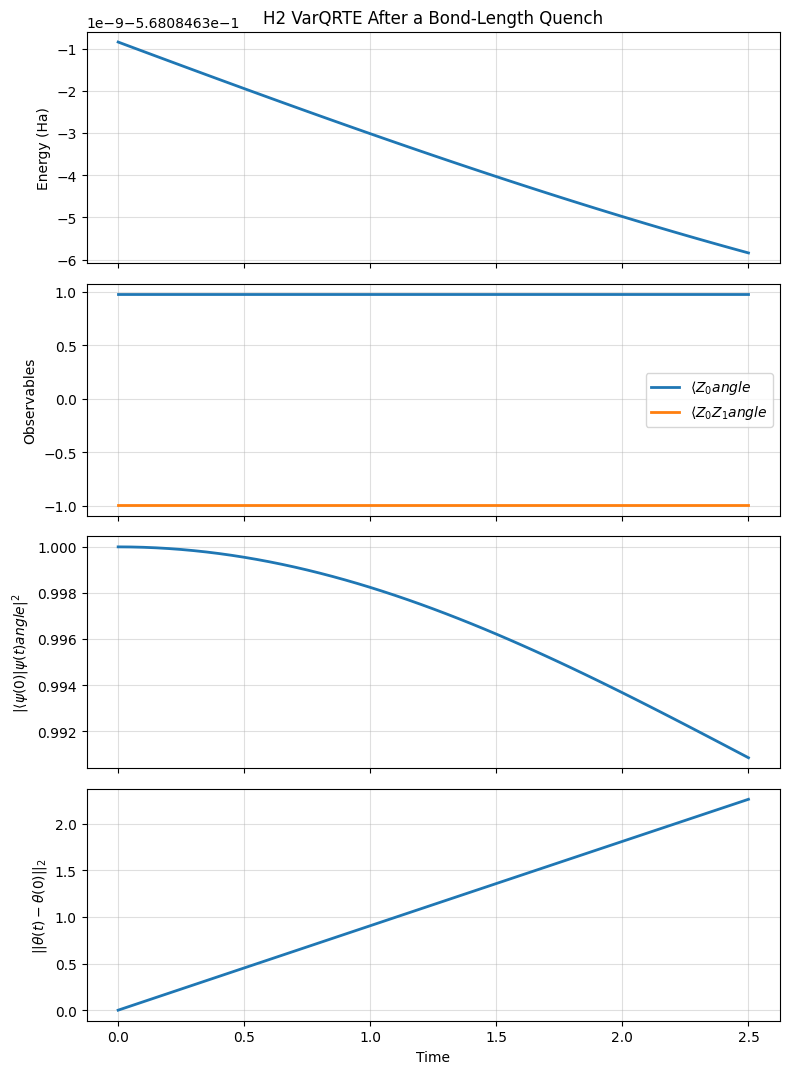

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(8, 11), sharex=True)

axes[0].plot(times, energies, lw=2)
axes[0].set_title("H2 VarQRTE After a Bond-Length Quench")
axes[0].set_ylabel("Energy (Ha)")
axes[0].grid(True, alpha=0.4)

axes[1].plot(times, z0_vals, lw=2, label=r"$\langle Z_0 \rangle$")
axes[1].plot(times, zz01_vals, lw=2, label=r"$\langle Z_0 Z_1 \rangle$")
axes[1].set_ylabel("Observables")
axes[1].grid(True, alpha=0.4)
axes[1].legend()

axes[2].plot(times, fidelities, lw=2)
axes[2].set_ylabel(r"$|\langle \psi(0)|\psi(t) \rangle|^2$")
axes[2].grid(True, alpha=0.4)

axes[3].plot(times, param_displacements, lw=2)
axes[3].set_xlabel("Time")
axes[3].set_ylabel(r"$||\theta(t)-\theta(0)||_2$")
axes[3].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
